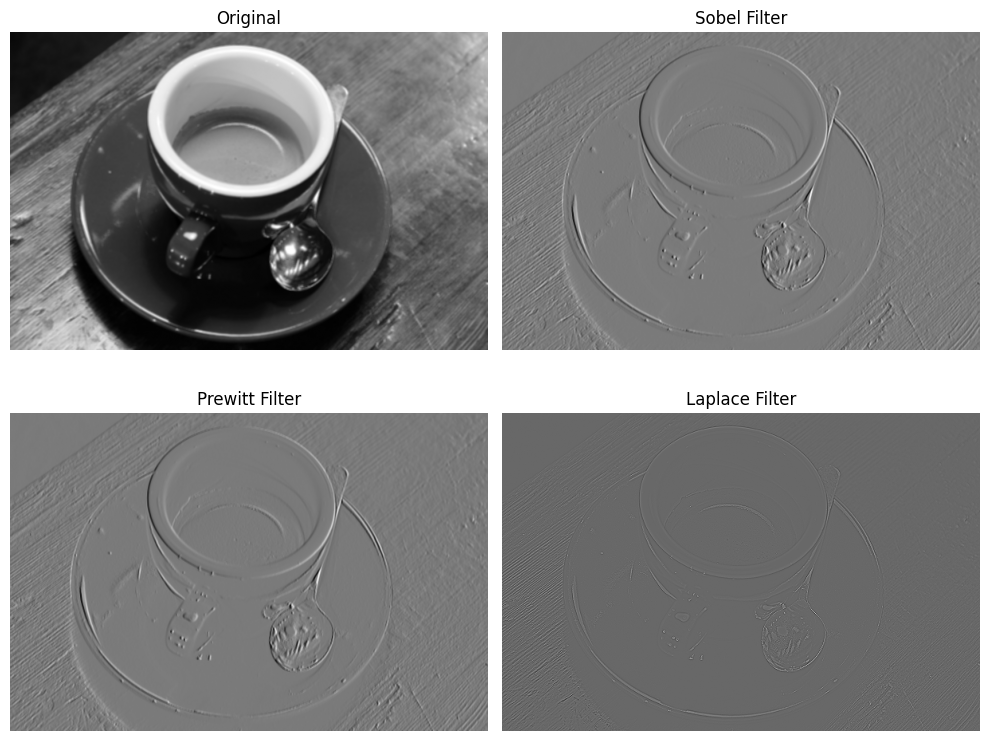

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage import data, color

image = color.rgb2gray(data.coffee())
prewitt_filter = np.array([[-1,0,1],
                           [-1,0,1],
                           [-1,0,1]])
sobel_filter = np.array([[-1,0,1],
                         [-2,0,2],
                         [-1,0,1]])
laplace_filter = np.array([[0,-3,0],
                           [-3,12,-3],
                           [0,-3,0]])

convolved_config = {
                'Original':[np.ones(prewitt_filter.shape),''],
                'Sobel Filter':[sobel_filter,''],
                'Prewitt Filter':[prewitt_filter,''],
                'Laplace Filter':[laplace_filter,'']
                }

for filter_ in convolved_config.keys():
    convolved_config[filter_][1] = convolve2d(image, convolved_config[filter_][0], mode='same', boundary='symm')

fig, axes = plt.subplots(2,2, figsize= (10,8))

for i, ax in enumerate(axes.flat):
    ax.imshow(list(convolved_config.values())[i][1], cmap='gray')
    ax.set_title(f'{list(convolved_config.keys())[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import math

def pooling(feature_map, pool_func, kernel_size=2, stride = 2):
    output_shape = (math.floor((feature_map.shape[0]-kernel_size)/stride)+1, math.floor((feature_map.shape[1]-kernel_size)/stride)+1)
    pooled_img = np.zeros(output_shape)
    for i in range(pooled_img.shape[0]):
        for j in range(pooled_img.shape[1]):
            pooled_img[i,j] = pool_func(feature_map[i*stride:(i*stride+kernel_size),j*stride:(j*stride+kernel_size)])
    return pooled_img

In [44]:
img = color.rgb2gray(data.astronaut())

In [ ]:
pooled_img = pooling(img, np.average, kernel_size=10)

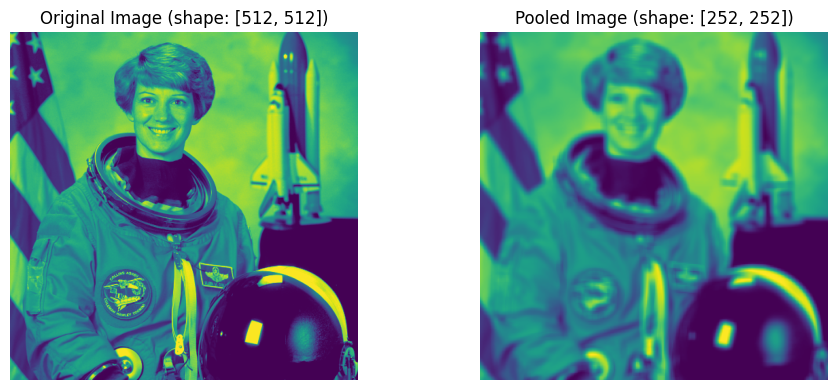

In [50]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.title(f'Original Image (shape: {list(img.shape)})')
plt.subplot(1,2,2)
plt.imshow(pooled_img)
plt.axis('off')
plt.title(f'Pooled Image (shape: {list(pooled_img.shape)})')
plt.tight_layout()
plt.show()